# W01 EDA Notebook — Synthetic Aido Rover Telemetry Data

## Problem Statement

The purpose of this notebook is to explore a synthetic Aido Rover telemetry dataset and identify which sensor features appear different between normal and fault operation. This early exploratory analysis will help guide later correlation analysis and regression modeling.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
# The file name contains spaces, so keep the exact name here.
data_path = "../data/synthetic rover data.csv"

df = pd.read_csv(data_path)

df.head()

,timestamp,unit_id,gps_lat,gps_lon,lidar_dist,battery_soc,torque_fl,torque_fr,torque_rl,torque_rr,ambient_temp,fault_label
0,2026-06-22 00:00:00,ROVER_01,37.387102,-121.979485,3.286,72.46,7.899,9.458,9.574,10.687,26.02,0
1,2026-06-22 00:01:00,ROVER_18,37.392078,-121.958254,2.843,57.83,3.922,8.088,5.485,4.936,19.68,0
2,2026-06-22 00:02:00,ROVER_11,37.395329,-121.966144,3.569,59.29,10.364,9.169,10.114,10.455,23.05,0
3,2026-06-22 00:03:00,ROVER_20,37.394625,-121.978246,3.284,70.02,5.074,10.203,6.993,8.247,20.36,0
4,2026-06-22 00:04:00,ROVER_12,37.392388,-121.964007,1.909,56.78,9.004,8.305,8.141,9.586,29.57,0


In [8]:
print("Dataset shape:", df.shape)

print("\nData types:")
print(df.dtypes)

Dataset shape: (15000, 12)

Data types:
timestamp           str
unit_id             str
gps_lat         float64
gps_lon         float64
lidar_dist      float64
battery_soc     float64
torque_fl       float64
torque_fr       float64
torque_rl       float64
torque_rr       float64
ambient_temp    float64
fault_label       int64
dtype: object


In [9]:
missing_values = df.isnull().sum()

print("Missing value report:")
print(missing_values)

Missing value report:
timestamp       0
unit_id         0
gps_lat         0
gps_lon         0
lidar_dist      0
battery_soc     0
torque_fl       0
torque_fr       0
torque_rl       0
torque_rr       0
ambient_temp    0
fault_label     0
dtype: int64


In [10]:
fault_counts = df["fault_label"].value_counts()
fault_rate = df["fault_label"].mean()

print("Fault label counts:")
print(fault_counts)

print("\nFault rate:", round(fault_rate, 4))

Fault label counts:
fault_label
0    13138
1     1862
Name: count, dtype: int64

Fault rate: 0.1241


In [11]:
df.describe()

,gps_lat,gps_lon,lidar_dist,battery_soc,torque_fl,torque_fr,torque_rl,torque_rr,ambient_temp,fault_label
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,37.387610,-121.972025,3.185068,64.328101,10.952687,10.968162,10.955092,10.941116,23.990436,0.124133
std,0.010000,0.009937,1.153512,17.412071,4.662813,4.662651,4.669045,4.671350,4.954226,0.329745
min,37.353479,-122.009054,0.100000,0.000000,-2.529000,-3.642000,-2.117000,-2.603000,6.310000,0.000000
25%,37.380932,-121.978706,2.489000,53.200000,7.965750,7.995000,8.001750,7.931750,20.610000,0.000000
50%,37.387637,-121.971982,3.061000,65.480000,10.421000,10.420500,10.395500,10.409000,24.005000,0.000000
75%,37.394287,-121.965261,3.684250,76.482500,13.089000,13.123000,13.079250,13.060250,27.340000,0.000000
max,37.429076,-121.928851,12.977000,100.000000,44.309000,41.229000,40.893000,42.593000,41.800000,1.000000


In [13]:
numeric_columns = [
    "gps_lat",
    "gps_lon",
    "lidar_dist",
    "battery_soc",
    "torque_fl",
    "torque_fr",
    "torque_rl",
    "torque_rr",
    "ambient_temp"
]

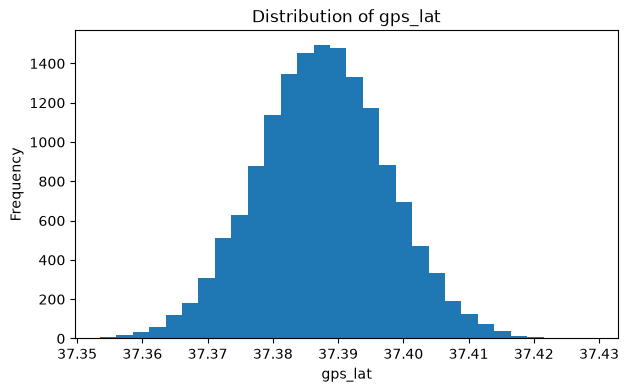

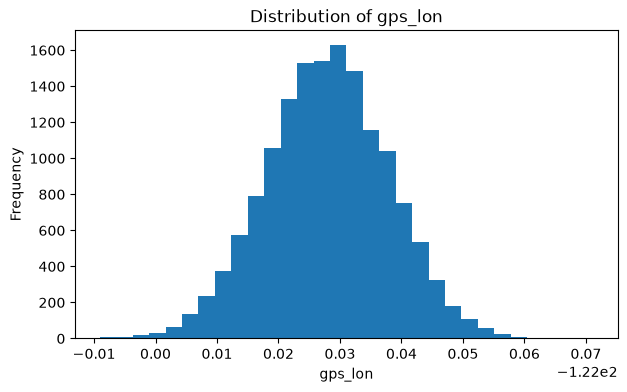

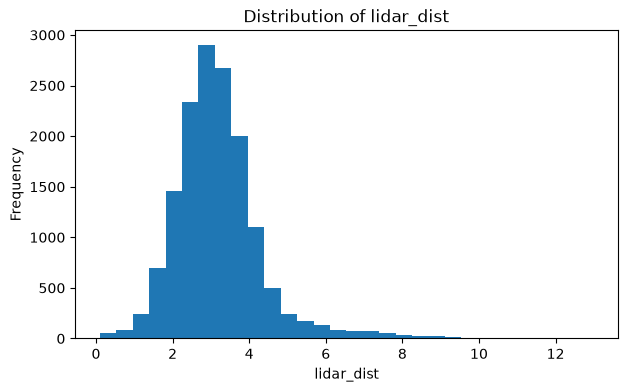

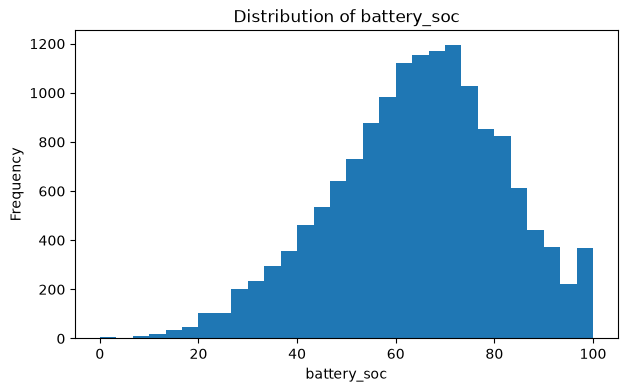

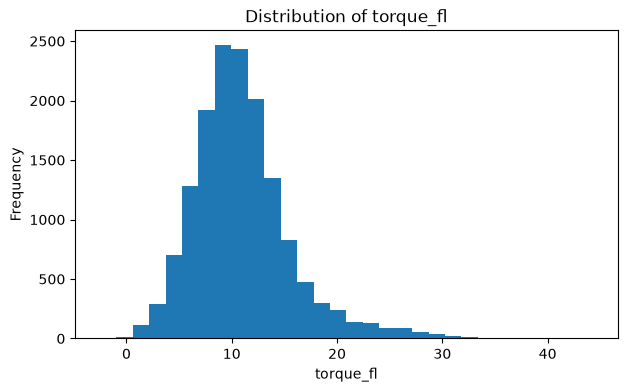

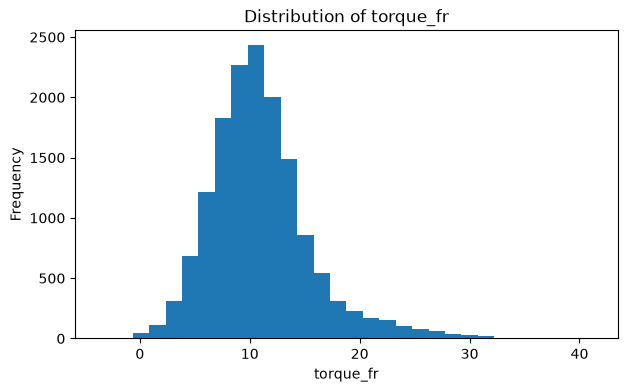

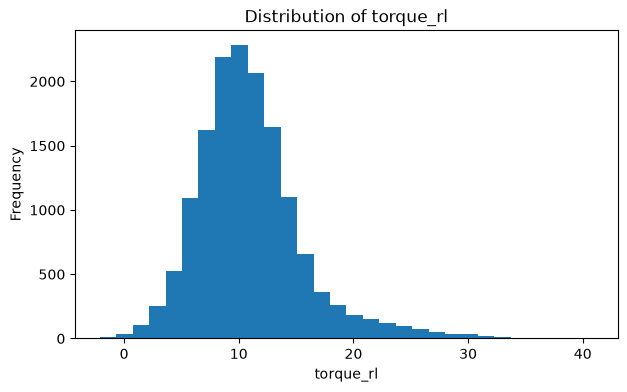

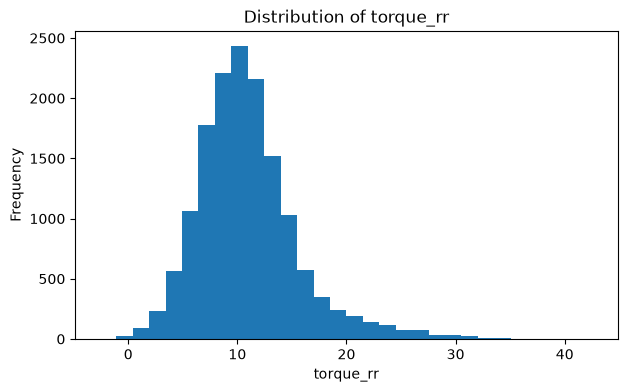

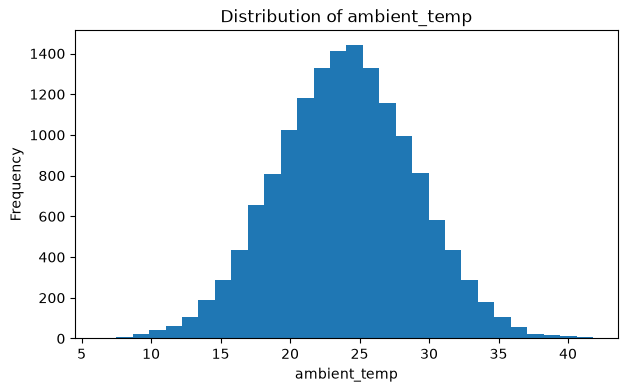

In [14]:
for col in numeric_columns:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

<Figure size 700x400 with 0 Axes>

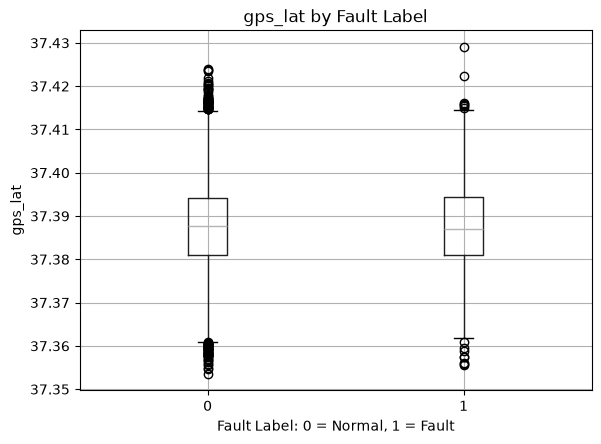

<Figure size 700x400 with 0 Axes>

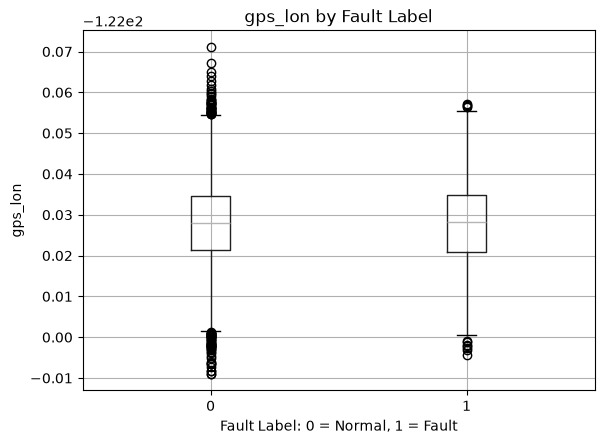

<Figure size 700x400 with 0 Axes>

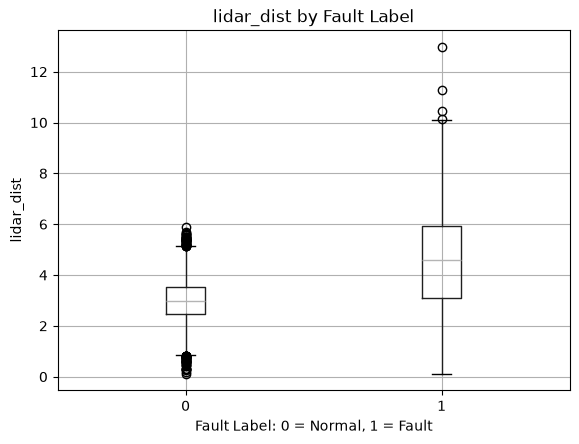

<Figure size 700x400 with 0 Axes>

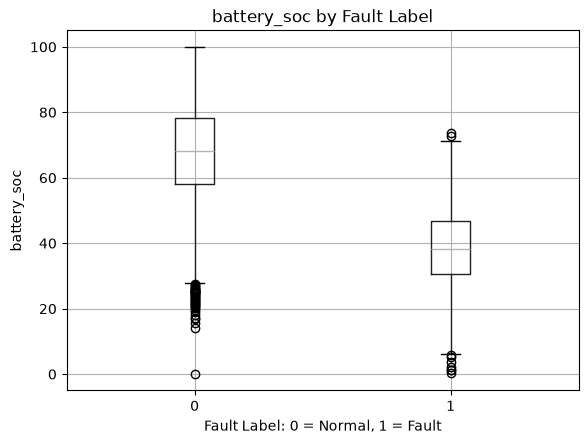

<Figure size 700x400 with 0 Axes>

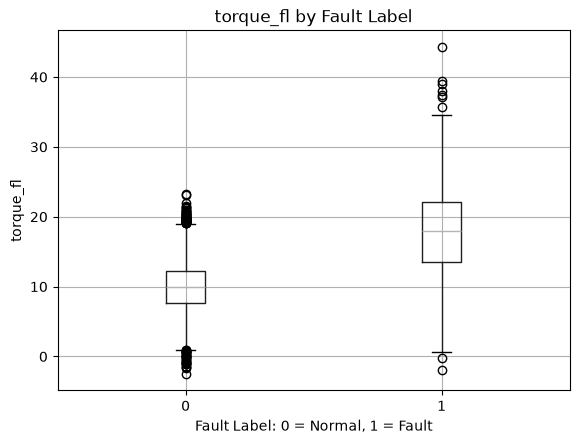

<Figure size 700x400 with 0 Axes>

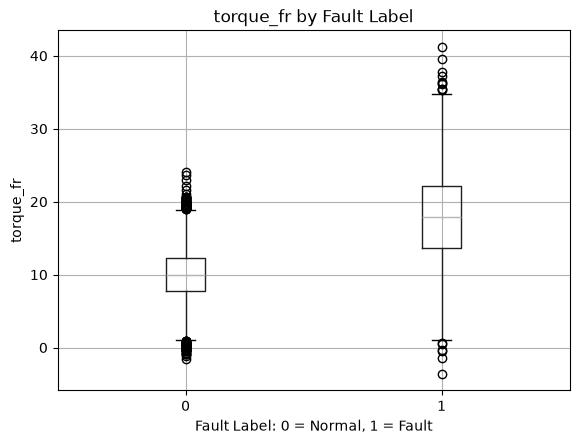

<Figure size 700x400 with 0 Axes>

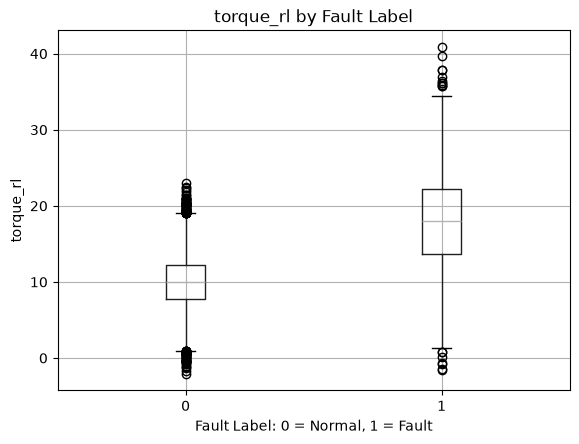

<Figure size 700x400 with 0 Axes>

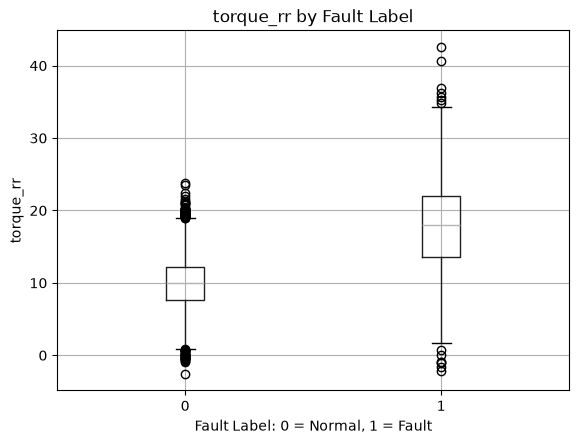

<Figure size 700x400 with 0 Axes>

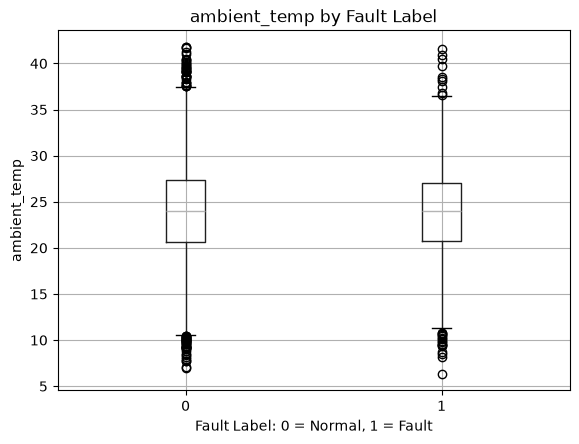

In [15]:
for col in numeric_columns:
    plt.figure(figsize=(7, 4))
    df.boxplot(column=col, by="fault_label")
    plt.title(f"{col} by Fault Label")
    plt.suptitle("")
    plt.xlabel("Fault Label: 0 = Normal, 1 = Fault")
    plt.ylabel(col)
    plt.show()

In [16]:
group_summary = df.groupby("fault_label")[numeric_columns].mean().round(2)

group_summary

,gps_lat,gps_lon,lidar_dist,battery_soc,torque_fl,torque_fr,torque_rl,torque_rr,ambient_temp
fault_label,,,,,,,,,
0,37.39,-121.97,2.99,68.00,9.97,9.97,9.97,9.95,24.01
1,37.39,-121.97,4.56,38.45,17.91,17.99,17.94,17.92,23.88


In [17]:
key_columns = [
    "battery_soc",
    "lidar_dist",
    "torque_fl",
    "torque_fr",
    "torque_rl",
    "torque_rr",
    "ambient_temp"
]

comparison = df.groupby("fault_label")[key_columns].mean().round(2)

comparison

,battery_soc,lidar_dist,torque_fl,torque_fr,torque_rl,torque_rr,ambient_temp
fault_label,,,,,,,
0,68.00,2.99,9.97,9.97,9.97,9.95,24.01
1,38.45,4.56,17.91,17.99,17.94,17.92,23.88


In [18]:
normal_means = df[df["fault_label"] == 0][key_columns].mean()
fault_means = df[df["fault_label"] == 1][key_columns].mean()

difference = (fault_means - normal_means).round(2)

difference

battery_soc    -29.55
lidar_dist       1.57
torque_fl        7.94
torque_fr        8.02
torque_rl        7.97
torque_rr        7.96
ambient_temp    -0.13
dtype: float64

## Preliminary Observations

The EDA results show clear differences between normal rows and fault rows.

First, fault rows have a much lower average battery state of charge than normal rows. This suggests that low battery level may be strongly associated with fault risk.

Second, fault rows have higher average LiDAR distance values. This may indicate that unstable distance sensing or more difficult navigation conditions are related to fault events.

Third, fault rows show higher wheel torque values across all four wheels. This suggests that mechanical load or uneven movement may be an important predictor of fault risk.

Ambient temperature does not show a strong difference between normal and fault rows in the initial group comparison.

Based on this exploratory analysis, battery state of charge, LiDAR distance, and wheel torque should be treated as candidate predictors for the next stage of correlation analysis and regression modeling.

This connects to the Tsinghua rental price regression methodology because both projects begin with exploratory analysis to identify variables that may explain an important outcome. In the Tsinghua project, the outcome was rental price. In this internship project, the outcome is Aido Rover fault status.